In [140]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import re

matrix_path = "/home/mengelsl/MA-bench-framework/matrices/spmv"

main_folder = {
    "Native": "/home/mengelsl/MA-bench-framework/outputs/SpMV_final/native/",
    "SME": "/home/mengelsl/MA-bench-framework/outputs/SpMV_final/sme/",
    "SME+SEV": "/home/mengelsl/MA-bench-framework/outputs/SpMV_final/sev/",
    "Native_interleave": "/home/mengelsl/MA-bench-framework/outputs/SpMV_final/native_interleave/",
    "SME_interleave": "/home/mengelsl/MA-bench-framework/outputs/SpMV_final/sme_interleave/",
    "SME+SEV_interleave": "/home/mengelsl/MA-bench-framework/outputs/SpMV_final/sev_interleave/",
}

results_list = []

for label, path in main_folder.items():
    f_path = os.path.join(path, "results.csv")
    if os.path.exists(f_path):
        df = pd.read_csv(f_path)
        df["Mode"] = label.replace("_interleave", "")
        df["VM_NUMA"] = "interleave" if "interleave" in label else "strict"
        results_list.append(df)

df_raw = pd.concat(results_list, ignore_index=True)
df_raw.rename(columns={"NUMA_Policy": "Process_NUMA"}, inplace=True)

print(f"Loaded {len(df_raw)} raw rows.")

Loaded 7200 raw rows.


In [116]:
config_cols = ["Mode", "Matrix", "Cores", "Process_NUMA", "VM_NUMA", "Iterations"]

metrics = [
    "IO_Time", "SpMV_Time", "SpMV_GFLOPS", "Perf_Cycles",
    "Perf_Instructions", "Perf_CacheMisses", "Perf_dTLBMisses",
    "Voluntary_CtxSwitches", "Involuntary_CtxSwitches",
    "Minor_Faults", "Major_Faults", "Peak_RSS"
]

config_drop_counts = []

def iqr_mark_outliers(group):
    group = group.copy()
    group_drops = 0

    for col in metrics:
        if col not in group.columns:
            continue
        
        data = pd.to_numeric(group[col], errors="coerce")
        valid = data.dropna()
        
        if valid.empty:
            continue
        
        q1, q3 = valid.quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        
        mask = (data >= lower) & (data <= upper)
        
        group_drops += (~mask & data.notna()).sum()
        
        # Mark outliers as NaN
        group.loc[~mask, col] = np.nan

    config_drop_counts.append(group_drops)
    return group

df_clean = (
    df_raw
    .groupby(config_cols)
    .apply(iqr_mark_outliers, include_groups=False)
    .reset_index()
)

total_points_removed = np.sum(config_drop_counts)

print(f"Total metric data points: {len(df_raw) * len(metrics)}")
print(f"Total data points removed: {total_points_removed}")
print(f"Data points removed (%): {total_points_removed / (len(df_raw) * len(metrics)) * 100:.2f}%")

Total metric data points: 86400
Total data points removed: 3146
Data points removed (%): 3.64%


In [117]:
def compute_cv_per_mode(df, config_cols, metrics):
    stats = (
        df
        .groupby(config_cols)[metrics]
        .agg(["mean", "std"])
    )
    
    cv = stats.xs("std", level=1, axis=1) / stats.xs("mean", level=1, axis=1)

    # Aggregate over Mode (first level)
    cv_mode = cv.groupby(level=0).mean()

    cv_mode.fillna(0, inplace=True)
    
    return cv_mode

cv_raw_mode = compute_cv_per_mode(df_raw, config_cols, metrics)
cv_clean_mode = compute_cv_per_mode(df_clean, config_cols, metrics)

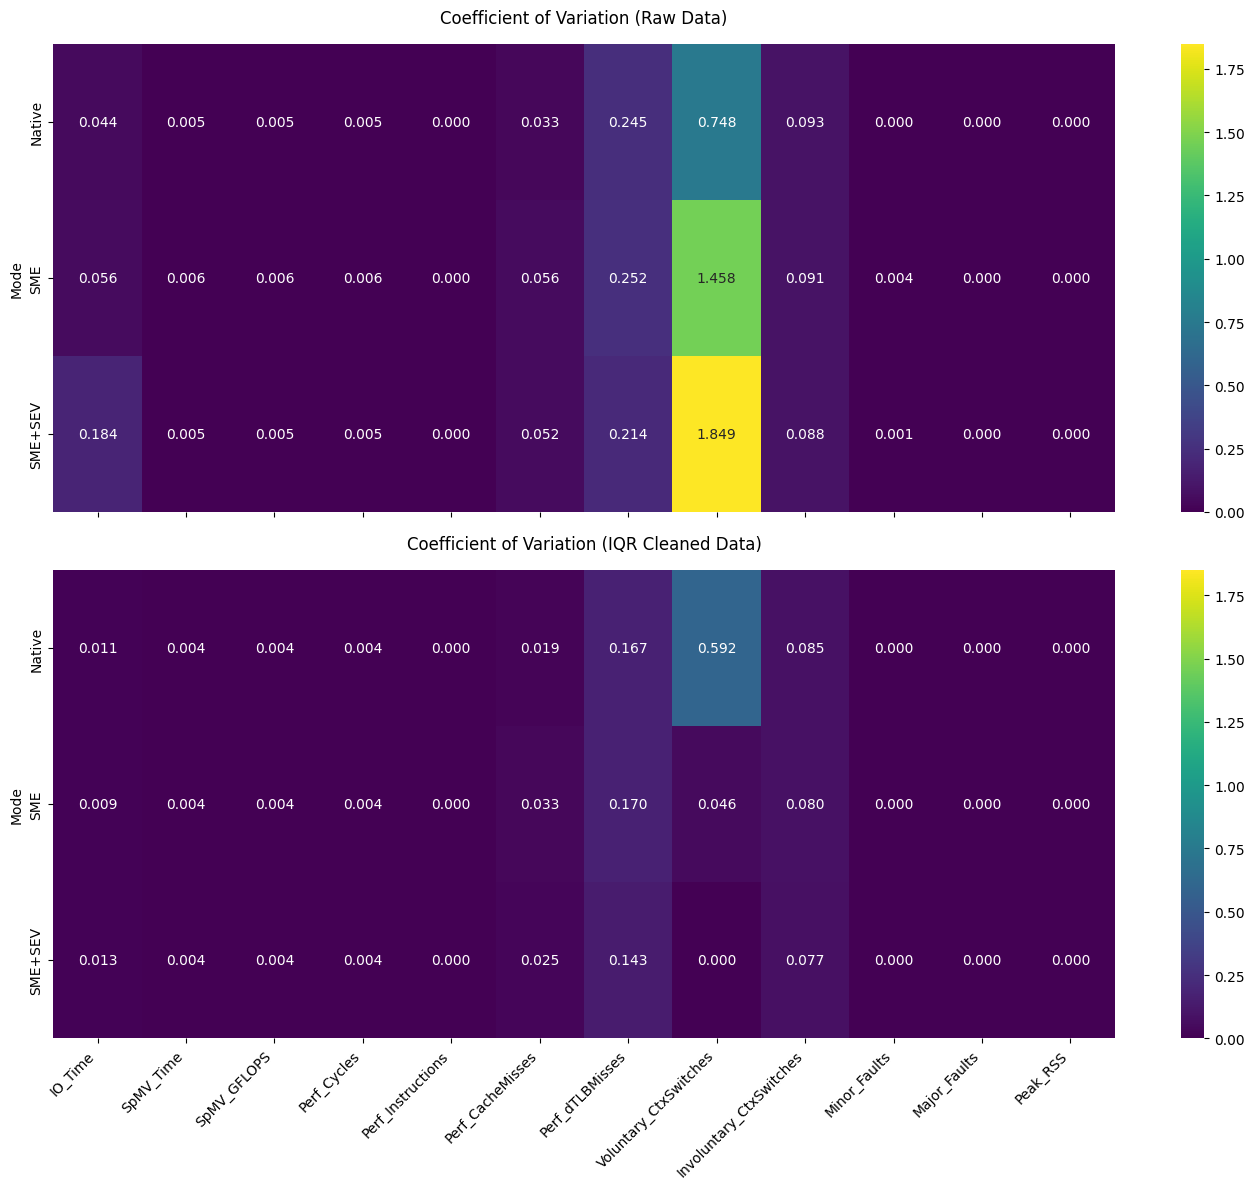

In [118]:
v_max = max(cv_raw_mode.max().max(), cv_clean_mode.max().max())

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

kwargs = dict(
    annot=True,
    fmt=".3f",
    cmap="viridis",
    vmin=0,
    vmax=v_max
)

sns.heatmap(cv_raw_mode, ax=ax1, **kwargs)
ax1.set_title("Coefficient of Variation (Raw Data)", pad=15)
ax1.set_ylabel("Mode")

sns.heatmap(cv_clean_mode, ax=ax2, **kwargs)
ax2.set_title("Coefficient of Variation (IQR Cleaned Data)", pad=15)
ax2.set_ylabel("Mode")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
# fully cleaned data
df = (
    df_clean
    .groupby(config_cols)[metrics]
    .mean()
    .reset_index()
)

def get_mb(n, randomness):
    r_str = str(randomness).replace('.', '-')
    f_path = os.path.join(matrix_path, f"{r_str}_N{int(n)}.bin")
    try:
        return round(os.path.getsize(f_path) / (1024**2))
    except: return None

df['N'] = df['Matrix'].str.extract(r'N(\d+)').fillna(0).astype(int)
r = df['Matrix'].str.extract(r'(\d)-(\d)')
df['Randomness'] = (r[0] + "." + r[1]).astype(float).fillna(0.0)
df['MB'] = df.apply(lambda row: get_mb(row['N'], row['Randomness']), axis=1).astype('Int64')
k = 30  # nnz per row
#2 operations per non-zero element (multiply and add)
# TODO: the cpp gflops were calculated wrong, delete everything regarding that
df['SpMV_GFLOPS'] = ( 2 * k * df['N']) / ( (df['SpMV_Time'] / df['Iterations']) * 1e9)
#based on 32MB L3 per 8 cores
L3_size = {
    1: 32,
    8: 32,
    24: 96,
    48: 192,
}
df['L3_fit'] = df['MB'] >= df['Cores'].map(L3_size)

df.head()

,Mode,Matrix,Cores,Process_NUMA,VM_NUMA,Iterations,IO_Time,SpMV_Time,SpMV_GFLOPS,Perf_Cycles,...,Perf_dTLBMisses,Voluntary_CtxSwitches,Involuntary_CtxSwitches,Minor_Faults,Major_Faults,Peak_RSS,N,Randomness,MB,L3_fit
0,Native,0-0_N1440352.bin,1,interleave,interleave,369,0.081598,9.948493,3.205450,3.613541e+10,...,363828.533333,0.0,19.466667,7.0,0.0,535676.0,1440352,0.0,500,True
1,Native,0-0_N1440352.bin,1,interleave,strict,369,0.081996,9.993496,3.191015,3.630301e+10,...,396131.642857,0.0,16.466667,7.0,0.0,535676.0,1440352,0.0,500,True
2,Native,0-0_N1440352.bin,1,membind,interleave,369,0.081822,9.946006,3.206251,3.612827e+10,...,346667.800000,0.0,20.785714,7.0,0.0,535676.0,1440352,0.0,500,True
3,Native,0-0_N1440352.bin,1,membind,strict,369,0.081674,9.991400,3.191684,3.630452e+10,...,345576.933333,0.0,16.733333,7.0,0.0,535676.0,1440352,0.0,500,True
4,Native,0-0_N1440352.bin,8,interleave,interleave,713,0.081576,10.268875,6.000488,2.962678e+11,...,16662.933333,0.0,101.200000,17.0,0.0,540250.4,1440352,0.0,500,True


In [137]:
df_native = df[df['Mode'] == 'Native'].copy()
df_other = df[df['Mode'] != 'Native'].copy()

merge_cols = ['Matrix', 'Cores', 'Process_NUMA', 'VM_NUMA']

# additional columns to keep
extra_cols = ['N', 'Randomness', 'MB', 'L3_fit']

df_merged = df_other.merge(
    df_native[merge_cols + metrics],
    on=merge_cols,
    suffixes=('', '_native')
)

# include extra columns in result
result = df_merged[['Mode'] + merge_cols + extra_cols].copy()

for m in metrics:
    native_col = f"{m}_native"

    result[f"{m}_abs"] = df_merged[m] - df_merged[native_col]

    result[f"{m}_pct"] = np.where(
        df_merged[native_col] != 0,
        (df_merged[m] - df_merged[native_col]) / df_merged[native_col] * 100,
        np.nan
    )

overhead_df = result

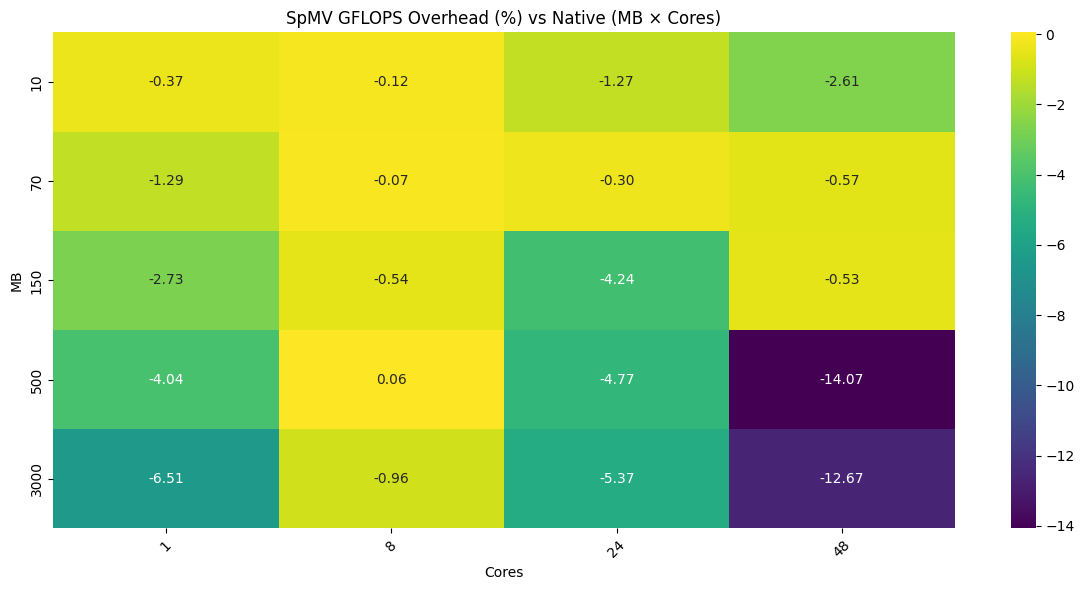

In [ ]:
metric = "SpMV_GFLOPS_pct"

heatmap_data = (
    overhead_df
    .groupby(["MB", "Cores"])[metric]
    .mean()
    .reset_index()
    .pivot(index="MB", columns="Cores", values=metric)
)

# Plot
plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)

plt.title("SpMV GFLOPS Overhead (%) vs Native (MB × Cores)")
plt.ylabel("MB")
plt.xlabel("Cores")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [143]:
iter_list = []

for label, base_path in main_folder.items():
    extra_path = os.path.join(base_path, "extra")
    if not os.path.exists(extra_path): continue
    
    for folder in os.listdir(extra_path):
        csv_p = os.path.join(extra_path, folder, "iter.csv")
        match = re.search(r'(\d-\d)_N(\d+)_c(\d+)_(\w+)', folder)
        
        if os.path.exists(csv_p) and match:
            it_df = pd.read_csv(csv_p)
            
            it_df['Randomness'] = float(match.group(1).replace('-', '.'))
            it_df['N'] = int(match.group(2))
            it_df['Cores'] = int(match.group(3))
            it_df['Process_NUMA'] = match.group(4)
            it_df['VM_NUMA'] = "interleave" if "interleave" in label else "strict"
            it_df['MB'] = get_mb(it_df['N'].iloc[0], it_df['Randomness'].iloc[0])
            
            iter_list.append(it_df)

# This takes ~1-2 minutes
df_iters = pd.concat(iter_list, ignore_index=True) if iter_list else pd.DataFrame()
print(f"Loaded {len(df_iters)} individual iterations.")

Loaded 408661650 individual iterations.


In [144]:
df_iters

,Run,Iter,Time,GFLOPS,Randomness,N,Cores,Process_NUMA,VM_NUMA,MB
0,1,1,0.003373,7.68614,0.0,432105,48,membind,strict,150
1,1,2,0.000194,133.55200,0.0,432105,48,membind,strict,150
2,1,3,0.000175,147.94800,0.0,432105,48,membind,strict,150
3,1,4,0.000248,104.46200,0.0,432105,48,membind,strict,150
4,1,5,0.000185,140.20700,0.0,432105,48,membind,strict,150
...,...,...,...,...,...,...,...,...,...,...
408661645,15,79,0.083400,6.21736,1.0,8642110,48,interleave,interleave,3000
408661646,15,80,0.083267,6.22727,1.0,8642110,48,interleave,interleave,3000
408661647,15,81,0.083428,6.21523,1.0,8642110,48,interleave,interleave,3000
408661648,15,82,0.083246,6.22882,1.0,8642110,48,interleave,interleave,3000
